In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Lab 6 - Fisher's Linear Discriminant and Logistic Regression
- For equations, refer to Bishop's book, Section 4.1.4 and the slides

# Part I - Fisher's Linear Discriminant for Binary Classification (2 classes)

## Data Generation and Visualisation
- First we'll use scikit-learn to generate 2 blobs of data in 2D, using the [make_blobs()](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html) function.
- The data consists of 600 points divided into 2 classes, 0 and 1.

In [110]:
from sklearn.datasets import make_blobs

In [118]:
X, y = make_blobs(n_samples=600, centers=2, n_features=2, random_state=0)

Let's confirm the data has two classes

In [ ]:
np.unique(y)

array([0, 1])

## Exercise 1
- Now create a scatter plot to visualise the generated data. 
- Make sure to paint each point based on the class they belong to, as shown in the Figure below.

<Axes: xlabel='zero', ylabel='one'>

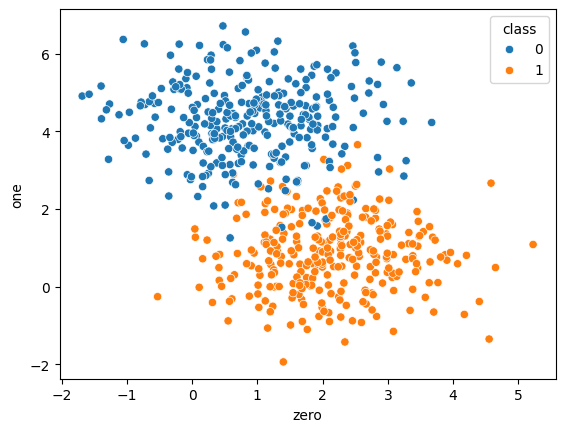

In [140]:
# your code goes here:

data = np.c_[X, y]
data = pd.DataFrame(data)
data.columns = ["zero", "one", "class"]
data["class"] = data["class"].astype(int)

sns.scatterplot(
    data,
    x="zero",
    y="one",
    hue="class"
)


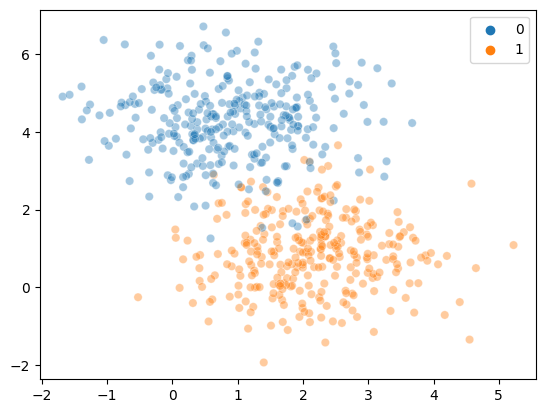
delete me

## Exercise 2
* Now plot a histogram of the data projected on each of the 2 dimensions of $X$ ($0$ and $1$)

As an example, below is a figure that shows the projection on dimension $1$.

_Tips:_ 
* You can either use `histplot()` to generate the plot, in which case it might be easier to pack $X$ and $y$ into a pandas DataFrame.
* Alternatively, considering that you will generate this plot many times throughout this lab, you can write a function that takes the projected vector and the class labels.
* Use 30 bins to obtain a similar plot.

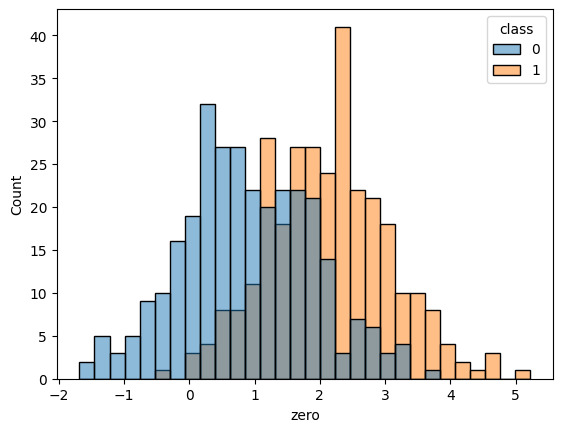

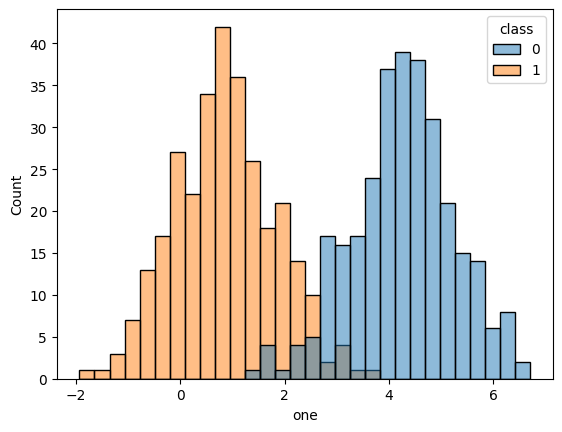

In [121]:
# your code goes here

sns.histplot(
    data,
    x="zero",
    hue="class",
    bins=30
)
plt.show()

sns.histplot(
    data,
    x="one",
    hue="class",
    bins=30
)
plt.show()




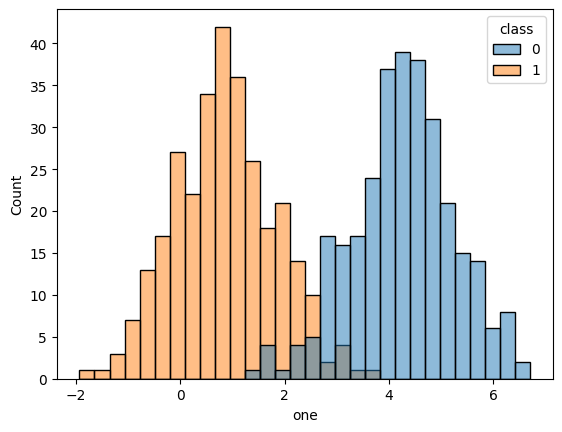
delete me

## Exercise 3 - Implement Fisher's linear discriminant

* Use numpy to calculate $\vec{w}$.
* Plot the data (as you did in Exercise 1), and add a line on the direction of $\vec{w}$ (reference Figure below).
* Project the points onto the calculated vector, and plot the projection (as you did in Exercise 2) (reference Figure below).

In [138]:
data = np.c_[X, y]
dim = len(X[0])
c1 = data[data[:,2] == 0][:,0:2]
c1

array([[ 1.61640160e+00,  2.68683128e+00],
       [ 3.03809631e-01,  3.94423417e+00],
       [ 6.75068326e-02,  3.87946971e+00],
       [ 2.92259181e-01,  5.96333812e+00],
       [-1.96853327e-01,  6.24740851e+00],
       [ 2.47225420e-01,  4.50034473e+00],
       [ 1.83419400e+00,  5.44488919e+00],
       [ 8.73051227e-01,  4.71438583e+00],
       [ 7.59320509e-01,  4.74918058e+00],
       [-2.12589179e-01,  3.79697097e+00],
       [-2.76525282e-01,  5.08127768e+00],
       [ 3.78954010e-01,  4.06586560e+00],
       [ 1.92352205e+00,  4.14877723e+00],
       [ 2.62440501e+00,  4.46801508e+00],
       [ 1.25619468e+00,  4.20563694e+00],
       [ 3.77616142e-01,  3.18789034e+00],
       [ 2.81702219e-01,  4.15415279e+00],
       [ 2.36707082e-01,  5.84680192e+00],
       [ 8.58106033e-01,  3.62360912e+00],
       [ 2.84220231e-01,  5.84016438e+00],
       [-2.02887852e-01,  5.60521540e+00],
       [ 6.11576534e-01,  4.46049118e+00],
       [-1.27929415e+00,  3.28128048e+00],
       [ 1.

In [145]:
# your code goes here:
def fishers_discriminat(X, y):
    data = np.c_[X, y]

    dim = len(X[0])

    c1 = data[data[:,2] == 0][:,0:2]
    c2 = data[data[:,2] == 1][:,0:2]

    size_c1 = len(c1)
    size_c2 = len(c2)

    m1 = np.sum(c1, axis=0)/size_c1
    m2 = np.sum(c2, axis=0)/size_c2

    S_w_c1 = np.zeros((dim,dim))
    S_w_c2 = np.zeros((dim,dim))

    for i in range(size_c1):
        S_w_c1 += (c1[i] - m1)[:,None]@(c1[i] - m1)[:,None].T

    for i in range(size_c2):
        S_w_c2 += (c2[i] - m1)[:,None]@(c2[i] - m1)[:,None].T

    S_w = S_w_c1 + S_w_c2

    w = np.linalg.inv(S_w)@(m2-m1)
    w = w/np.linalg.norm(w)

    return w


[ 0.35086946 -0.93642438]
[ 0.93642438  0.90804789  0.87967139  0.85129489  0.8229184   0.7945419
  0.7661654   0.73778891  0.70941241  0.68103591  0.65265942  0.62428292
  0.59590642  0.56752993  0.53915343  0.51077694  0.48240044  0.45402394
  0.42564745  0.39727095  0.36889445  0.34051796  0.31214146  0.28376496
  0.25538847  0.22701197  0.19863547  0.17025898  0.14188248  0.11350599
  0.08512949  0.05675299  0.0283765   0.         -0.0283765  -0.05675299
 -0.08512949 -0.11350599 -0.14188248 -0.17025898 -0.19863547 -0.22701197
 -0.25538847 -0.28376496 -0.31214146 -0.34051796 -0.36889445 -0.39727095
 -0.42564745 -0.45402394 -0.48240044 -0.51077694 -0.53915343 -0.56752993
 -0.59590642 -0.62428292 -0.65265942 -0.68103591 -0.70941241 -0.73778891
 -0.7661654  -0.7945419  -0.8229184  -0.85129489 -0.87967139 -0.90804789
 -0.93642438 -0.96480088 -0.99317737 -1.02155387 -1.04993037 -1.07830686
 -1.10668336 -1.13505986 -1.16343635 -1.19181285 -1.22018935 -1.24856584
 -1.27694234 -1.30531883 -

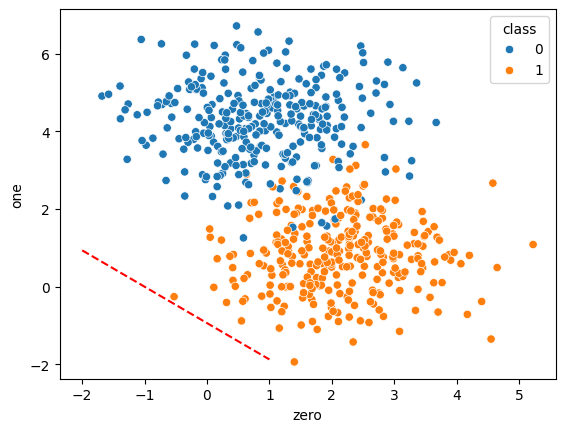

In [150]:
# your code goes here:

w = fishers_discriminat(X, y)
eixo_x = np.linspace(-2, 1, 100)
print(w)

eixo_y = w[1]*eixo_x + w[1]
print(eixo_y)

sns.scatterplot(
    data,
    x="zero",
    y="one",
    hue="class"
)

plt.plot(
    eixo_x,
    eixo_y,
    "--r"
)


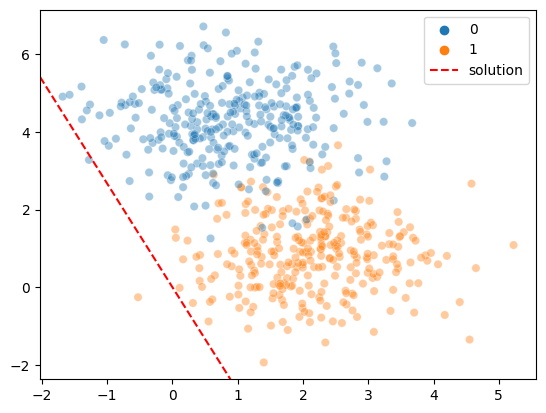
delete me

In [8]:
# your code goes here:


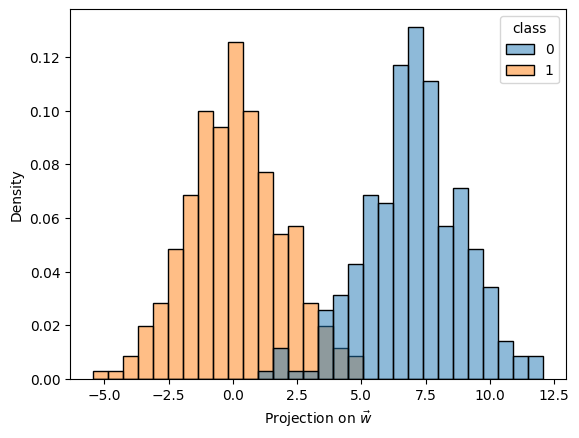
delete me

## Exercise 4

* In this exercise you will use the `RidgeClassifier` from sklearn (as shown below) to obtain the class predictions from different types of projections:
    * component 0 of the data
    * component 1 of the data
    * the calculated vector $\vec{w}$
    
* Calculate the accuracy of these predictions using `accuracy_score` from sklearn.

In [31]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import RidgeClassifier

In [ ]:
# Follow this structure for each projection:
r = RidgeClassifier()
r.fit(projection, y)
predicted_y = r.predict(projection)
accuracy = accuracy_score(predicted_y, y)

In [62]:
# your code goes here:


projection: first dimension, accuracy = 0.7366666666666667
projection: second dimension, accuracy = 0.955
projection: Fisher's linear discriminant, accuracy = 0.965


# Part II - Generalised Linear Discriminant (multi-class)

**NOTE:** For this part you will be using a multi-class estimator from scikit-learn (read the [documentation](https://scikit-learn.org/stable/modules/lda_qda.html#lda-qda)).

## Exercise 1 - Generate data

* Generate a 3 classes dataset in 2D, with the same rules as before (make 300 points per class)
* Plot the data and then similar histograms (on each dimension) as Part I Exercises 1 and 2.

In [9]:
# your code goes here: 


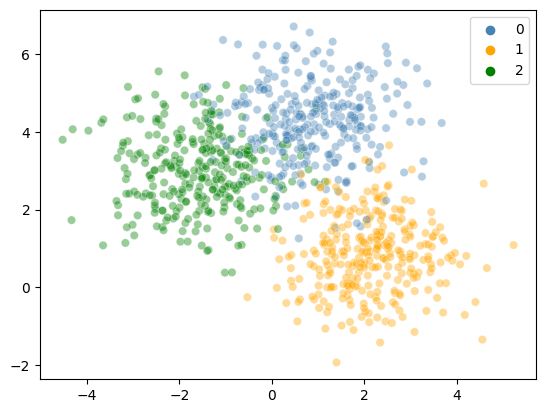
delete me

In [10]:
# your code goes here:


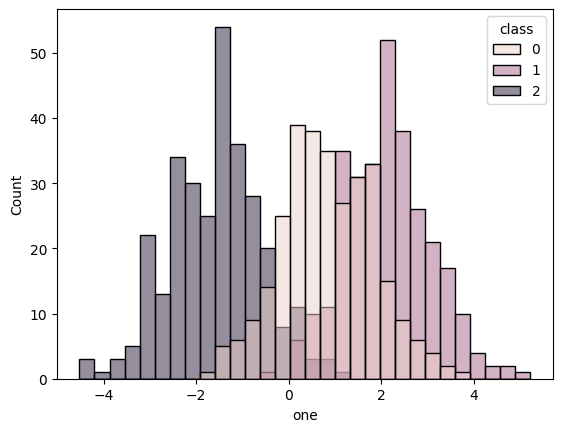
delete me

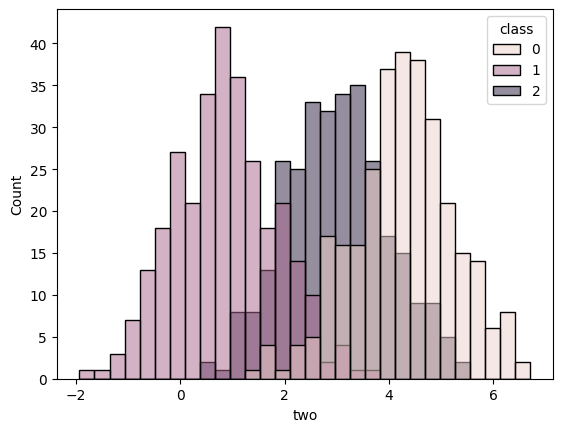
delete me

## Exercise 2 - Linear Discriminant Analysis

* Use sklearn's implementation of LDA to project the points in a single dimension and then plot the projected data

In [30]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

Remember that since we want to project our data onto a vector, the parameter n_components of `LinearDiscriminantAnalysis` should be set to 1

In [11]:
# your code goes here: 


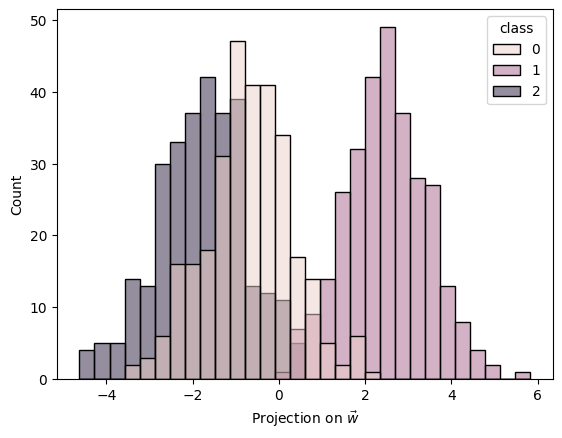
delete me

## Exercise 3 - Calculate test set accuracy

* use the default parameters for the LDA classifier, and report the prediction accuracy on a train/test split of 70/30% (use `random_state=0`)
* report also the accuracy of the `RidgeClassfier` you used in Part I 

In [32]:
from sklearn.model_selection import train_test_split

In [12]:
# your code goes here:


Test Accuracies:
LDA classifier: 0.937037037037037
Ridge Classifier fitting: 0.9259259259259259
